<a href="https://colab.research.google.com/github/mokhivibes/ml_course_hometasks/blob/main/11_Hometasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df1 = sns.load_dataset('titanic').dropna(subset=['age', 'fare'])
sns.set_theme(style="whitegrid", context='notebook')
#


Topshiriq 1 — Titanic: Yosh va Narx
TODO 1a:  age va fare orasida scatter plot chizing


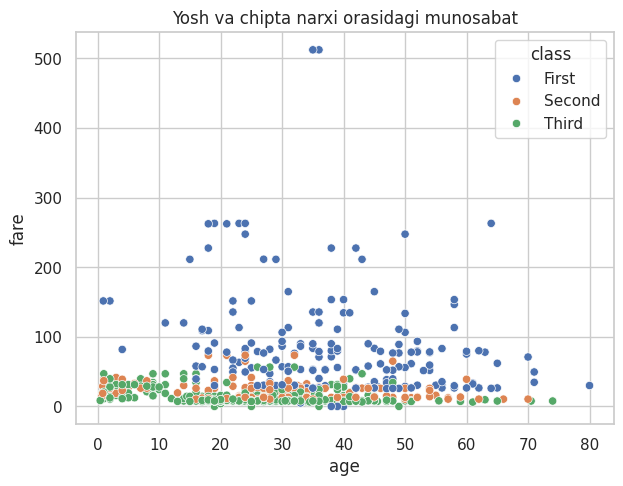

In [17]:
# TODO 1a: age vs fare scatter plot chizing
# hue='class' qo'shing (First/Second/Third)
# title: "Yosh va chipta narxi orasidagi munosabat"


sns.scatterplot(data=df1, x='age', y='fare', hue='class')
plt.tight_layout()
plt.title("Yosh va chipta narxi orasidagi munosabat")
plt.show()

TODO 1b:  Pearson r hisoblang — age va fare orasida


In [18]:
# TODO 1b: Pearson r hisoblang — age va fare orasida
r = np.corrcoef(df1['age'], df1['fare'])[0, 1]
print(f'r = {r:.4f}')


r = 0.0961


Savollar:
r qiymatini yozing va izohlang — kuchli yoki zaif bog'liqlikmi?
First class yo'lovchilari scatter da qayerda to'plangan? Nima uchun?
Yosh oshsa chipta narxi ham oshadi deb aytish mumkinmi? Asoslang.


Javob: 1. r = 0.0961, zaif bog'liqlik chunki kamida 0.5 dan yuqori bo'lish kerak kuchli bog'liqlik bo'lishi uchun.
2. 20 va 60 yosh oralig'ida lekin ba'zi outlierlarni hisobga olmasak asosan fare 50 va 200 orasida.
3. Yo'q chunki yosh oshgan sari baribir chipta narxi o'zgargani yo'q va buni biz correlation javobidan ham bilib olsak bo'ladi.

Topshiriq 2 — Diamonds: Og'irlik va Narx

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df2 = sns.load_dataset('diamonds')


TODO 2a:  carat vs price — to'liq dataset scatter


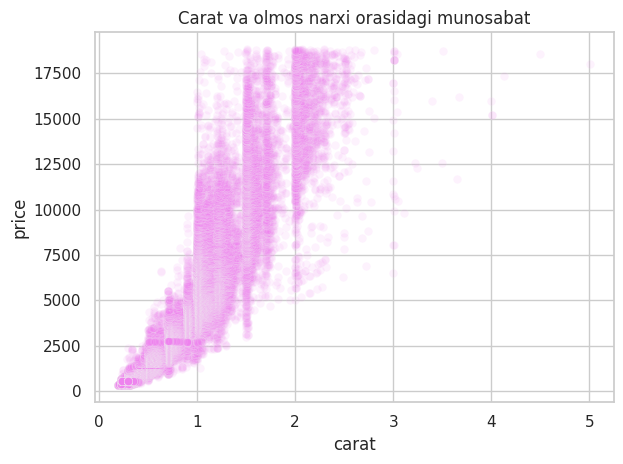

In [21]:
# TODO 2a: carat vs price scatter plot chizing
# alpha=0.1 (nuqtalar ko'p, shaffoflik kerak)

sns.scatterplot(data=df2, x='carat', y='price', alpha=0.1, c='violet')
plt.title('Carat va olmos narxi orasidagi munosabat')
plt.tight_layout()
plt.show()

In [22]:
df2.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


TODO 2b:  cut bo'yicha alohida scatter (1000 ta namuna)


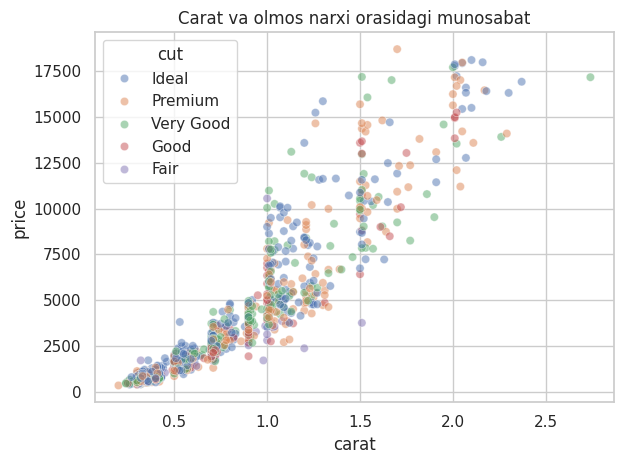

In [26]:
# TODO 2b: cut bo'yicha alohida — hue='cut'
# faqat 1000 ta namuna oling (df.sample(1000))

df_sample = df2.sample(1000)
sns.scatterplot(data=df_sample, x='carat', y='price', alpha=0.5, c='violet', hue='cut')
plt.title('Carat va olmos narxi orasidagi munosabat')
plt.tight_layout()
plt.show()

TODO 2c:  Pearson r va Log transform bilan r hisoblang


In [31]:
# TODO 2c: Pearson r hisoblang — carat va price orasida
# Log transform bilan ham hisoblang:
# np.corrcoef(np.log1p(df['carat']), np.log1p(df['price']))[0,1]

r = np.corrcoef(df_sample['carat'], df_sample['price'])[0, 1]
print(f'r = {r:.4f}')

log_r = np.corrcoef(np.log1p(df_sample['carat']), np.log1p(df_sample['price']))[0, 1]
print(f'Log transformed r (correlation coeff) is {log_r:.4f}')

r = 0.9265
Log transformed r (correlation coeff) is 0.9552


Savollar:
4. carat va price orasidagi r qiymatini yozing.
5. Log transform qo'shganda r qiymati o'zgaradimi? Nima uchun?
6. Scatter da qanday "guruhlar" ko'rinadi? Sababi nima deb o'ylaysiz?



In [32]:
#4. => r = 0.9265
#5. Ha biroz o'zgaradi chunki log transform qo'llanilganida katta outlier qiymatlar ko'p tarqalgan qiymatlarga yaqinlashtiriladi.
#6. Cut column dagi guruhlar ko'rinyapti chunki hue ga biz cut column nomini berib qo'yganmiz va o'sha column dagi value larni guruhlarga bo'lib ko'rsatadi

Topshiriq 3 — Diamonds: Korrelyatsiya Heatmap

In [34]:
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']



TODO 3a:  Korrelyatsiya matritsasini hisoblang


In [35]:
# TODO 3a: Numeric ustunlar korrelyatsiya matritsasini hisoblang
# ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

corr_matrix = df2[numeric_cols].corr()
corr_matrix

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


TODO 3b:  sns.heatmap() chizing


<Axes: >

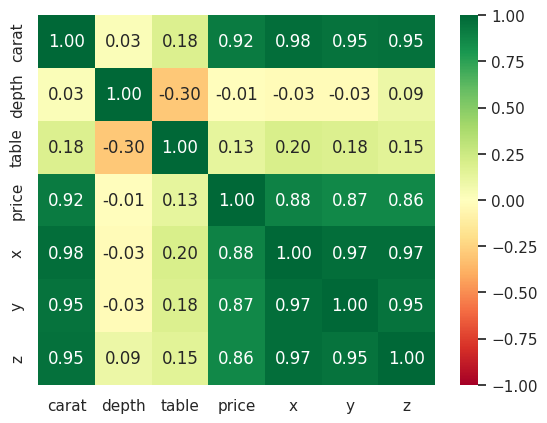

In [37]:
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1)

TODO 3c:  price bilan korelyatsiyani saralang


In [42]:
# TODO 3c: price bilan eng kuchli va eng zaif bog'liq ustunni aniqlang
corr_with_price = df2[numeric_cols].corr()['price'].sort_values(ascending=False)
print(corr_with_price)
# sns.heatmap(corr_with_price.to_frame())


price    1.000000
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64


Savollar:
7. price bilan eng kuchli bog'liq ustun qaysi? r = ?
8. depth va price orasidagi korrelyatsiya manfiymi? Bu nima anglatadi?
9. x, y, z ustunlari bir-biriga juda o'xshash korrelyatsiyaga ega — nima uchun?



In [ ]:
#7. price bilan eng kuchli bog'liq ustun carat r => 0.921591
#8. Ha, depth va price orasidagi korrelyatsiya manfiy. Bu teskari korrelyatsiyani anglatadi ya'ni depth ko'tarilgani sari narx pasayib boradi.
#9. Chunki x, y, z bular olmosning o'lchov birliklari, uzunlik, kenglik va balandlik ular qanchalik kottalashib borsa olmos narxi ham shunga qarab oshib boradi


Topshiriq 4 — Tips: Regplot va Guruhlar

In [45]:
df3 = sns.load_dataset('tips')


TODO 4a:  total_bill vs tip — sns.regplot() chizing


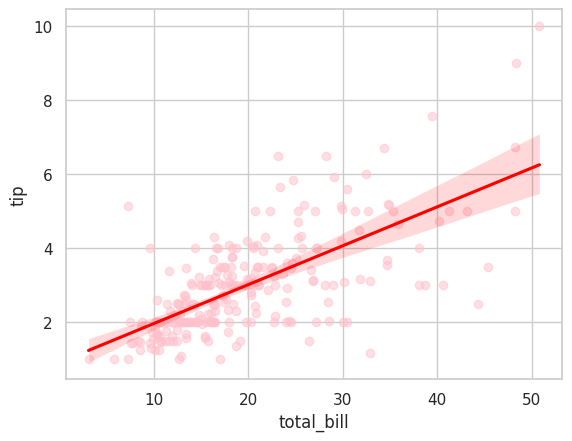

In [48]:
# TODO 4a: total_bill vs tip — sns.regplot() chizing

sns.regplot(data=df3, x='total_bill', y='tip', ci=95, color='red', scatter_kws={'color': 'pink', 'alpha':0.5} )
plt.show()

TODO 4b:  Kechki va tushlik alohida taqqoslash


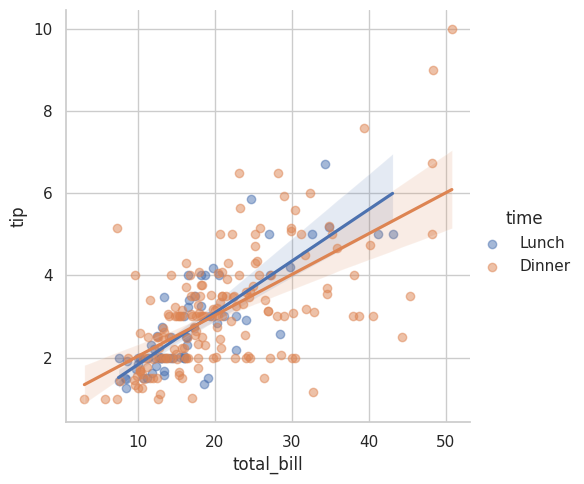

In [51]:
# TODO 4b: Kechki va tushlik alohida taqqoslash
# sns.lmplot(data=df, x='total_bill', y='tip', hue='time')

sns.lmplot(data=df3, x='total_bill', y='tip', hue='time', scatter_kws={'alpha':0.5})
plt.show()

TODO 4c:  stats.pearsonr() — Lunch va Dinner alohida


In [52]:
# TODO 4c: stats.pearsonr() — Lunch va Dinner alohida
from scipy import stats
lunch  = df3[df3['time'] == 'Lunch']
dinner = df3[df3['time'] == 'Dinner']

r_lunch,  p_lunch  = stats.pearsonr(lunch['total_bill'],  lunch['tip'])
r_dinner, p_dinner = stats.pearsonr(dinner['total_bill'], dinner['tip'])

print(f'Lunch:  r={r_lunch:.4f}, p={p_lunch:.4f}')
print(f'Dinner: r={r_dinner:.4f}, p={p_dinner:.4f}')


Lunch:  r=0.8054, p=0.0000
Dinner: r=0.6329, p=0.0000


Savollar:
10. Lunch va Dinner uchun r qiymatlarini taqqoslang — qaysi biri kuchliroq?
11. p-value ikkalasida ham < 0.05 mi? Bu nima anglatadi?
12. Kechki ovqatda tip ko'proqmi yoki kamroq? Scatter dan ko'rish mumkinmi?


In [ ]:
#10. Lunch kuchliroq ya'ni tip lunch vaqtida ko'proq bo'ladi (r=0.8054)
#11. Ha p < 0.05 ikkalasida ham,  bu natijaning tasodif bo'lish ehtimolini anglatadi ya'ni hozirgi holatda p 0 ga teng bo'lsa demak statistik to'g'ri natija degani
#12. Kechki ovqatda tip ko'proq, ha ko'rishimiz mumkib va tipning ko'p yoki kam bo'lishi odamlarning lunch va dinner payti qancha harajat (bill) qilishlariga ham bog'liq


Topshiriq 5 — Flights: Pairplot va Trend

In [53]:
df4 = sns.load_dataset('flights')


TODO 5a:  year vs passengers — regplot bilan trend


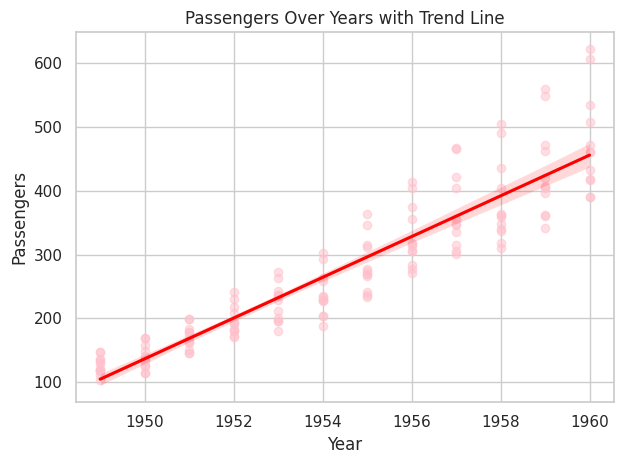

In [74]:
# TODO 5a: year vs passengers scatter — regplot bilan trend chizing

sns.regplot(data=df4, x='year', y='passengers', ci=95, color='red', scatter_kws={'color': 'pink', 'alpha':0.5} )
plt.title('Passengers Over Years with Trend Line')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.tight_layout()
plt.show()


TODO 5b:  Har bir oy uchun o'rtacha passengers — bar chart


/tmp/ipykernel_1958/3163743348.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_month = df4.groupby('month')['passengers'].mean()


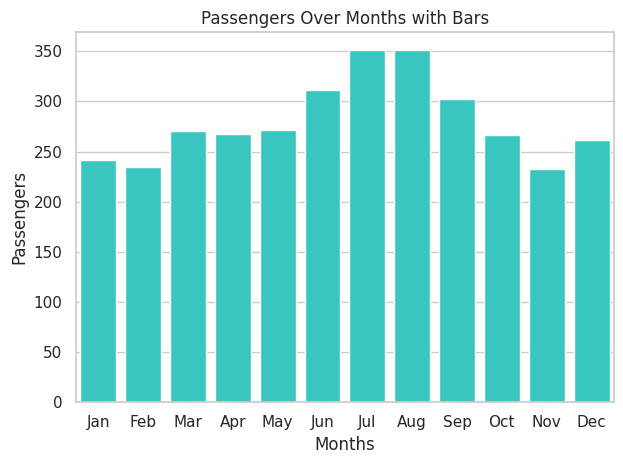

In [75]:
# TODO 5b: Har bir oy uchun o'rtacha passengers hisoblang
# df.groupby('month')['passengers'].mean()
# Natijani bar chart ko'rinishida chizing

mean_month = df4.groupby('month')['passengers'].mean()
mean_month

sns.barplot(data=mean_month, color='#22DDD6')
plt.title('Passengers Over Months with Bars')
plt.xlabel('Months')
plt.ylabel('Passengers')
plt.tight_layout()
plt.show()

TODO 5c:  Pearson va Spearman r — taqqoslang


In [80]:
# TODO 5c: year va passengers orasida Pearson r hisoblang
# Keyin Spearman r ham hisoblang (scipy.stats.spearmanr)
# Ikkalasini taqqoslang
r_flight = np.corrcoef(df4['year'], df4['passengers'])[0, 1]
print(f'r_flight = {r_flight:.4f}')
spear_r = stats.spearmanr(df4['year'], df4['passengers'])[0]
print(f'spear_r = {spear_r:.4f}')

r_flight = 0.9218
spear_r = 0.9505


TODO 5d:  Eng ko'p va eng kam yo'lovchi oylarini belgilang


In [89]:
# TODO 5d: Eng ko'p yo'lovchi bo'lgan oy va eng kam bo'lgan oyni toping
# scatter da ularni boshqa rangda belgilang

monthly_mean = df4.groupby('month')['passengers'].mean().round(0)



busiest_month = monthly_mean.idxmax()   # month name with the highest average
busiest_value = monthly_mean.max()      # the actual average value

quietest_month = monthly_mean.idxmin()  # month name with the lowest average
quietest_value = monthly_mean.min()     # the actual average value

print(f'Busiest month: {busiest_month} (avg passengers = {busiest_value})')
print(f'Quietest month: {quietest_month}')



Busiest month: Jul (avg passengers = 351.0)
Quietest month: Nov


/tmp/ipykernel_1958/1273449647.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_mean = df4.groupby('month')['passengers'].mean().round(0)


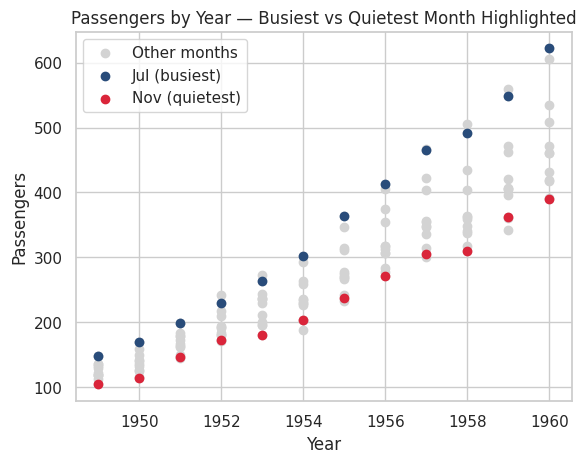

In [94]:
busiest_rows = df4[df4['month'] == busiest_month]
quietest_rows = df4[df4['month'] == quietest_month]
plt.scatter(df4['year'], df4['passengers'], color='lightgray', label='Other months')
plt.scatter(busiest_rows['year'], busiest_rows['passengers'], color='#294C7A', label=f'{busiest_month} (busiest)')
plt.scatter(quietest_rows['year'], quietest_rows['passengers'], color='#DA253A', label=f'{quietest_month} (quietest)')

plt.legend()
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.title('Passengers by Year — Busiest vs Quietest Month Highlighted')
plt.show()


Savollar:
13. year va passengers orasidagi Pearson r va Spearman r qiymatlarini yozing. Farq bormi?
14. Qaysi oy har doim eng ko'p yo'lovchiga ega? Sababi nima deb o'ylaysiz?
15. Bu trend (yillar o'tishi bilan o'sish) korrelyatsiyami yoki sabab-natijami? Tushuntiring.
16. Spearman va Pearson bir-biriga yaqin bo'lsa nima anglatadi?



In [ ]:
#13. r_flight = 0.9218 / spear_r = 0.9505 Ha farq bor ammo juda kichik miqdorda
#14. Iyul oyi, ko'pchilik shu oyda sayohat qilishi ehtimoli yuqorilig tufayli bo'lsa kerak.
#15. Korrelyatsiya chunki, "yil" o'zi hech narsaga bevosita sabab bo'lmaydi boshqa omillar (siyosiy kelishmovchiliklar, iqtisodiy o'sish va boshqalar) ta'sir qilsagina sabab-natija bo'ladi
#16. Bog'liqlik nafaqat monoton (spearman), balki sezilarli darajada chiziqliga (pearson) ham yaqin ekanini bildiradi.